In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [3]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
Updating files:  32% (1221/3783)
Updating files:  33% (1249/3783)
Updating files:  34% (1287/3783)
Updating files:  35% (1325/3783)
Updating files:  36% (1362/3783)
Updating files:  37% (1400/3783)
Updating files:  38% (1438/3783)
Updating files:  39% (1476/3783)
Updating files:  40% (1514/3783)
Updating files:  41% (1552/3783)
Updating files:  42% (1589/3783)
Updating files:  43% (1627/3783)
Updating files:  44% (1665/3783)
Updating files:  45% (1703/3783)
Updating files:  46% (1741/3783)
Updating files:  47% (1779/3783)
Updating files:  48% (1816/3783)
Updating files:  49% (1854/3783)
Updating files:  50% (1892/3783)
Updating files:  51% (1930/3783)
Updating files:  52% (1968/3783)
Updating files:  53% (2005/3783)
Updating files:  54% (2043/3783)
Updating files:  55% (2081/3783)
Updating files:  56% (2119/3783)
Updating files:  57% (2157/3783)
Updating files:  58% (2195/3783)
Updating files:  59% (2232/3783)
Updating files:  60% (2270/3783)
Up

In [6]:
train_path = 'clothing-dataset-small/train'
val_path = 'clothing-dataset-small/validation'
test_path = 'clothing-dataset-small/test'

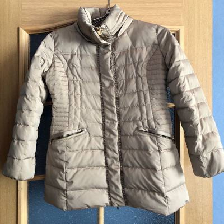

In [10]:
item = 'clothing-dataset-small/train/outwear/00149032-3dd6-426e-9bc0-d53032536a42.jpg'

img = load_img(item, target_size=(224,224))
img

In [11]:
x = np.array(img)
X = np.array([x])
X

array([[[[199, 166, 115],
         [200, 167, 116],
         [202, 169, 118],
         ...,
         [143, 185, 233],
         [143, 185, 233],
         [143, 185, 233]],

        [[196, 163, 112],
         [198, 165, 114],
         [201, 168, 117],
         ...,
         [142, 184, 232],
         [142, 184, 232],
         [141, 183, 231]],

        [[200, 167, 116],
         [201, 168, 117],
         [202, 169, 118],
         ...,
         [141, 183, 231],
         [140, 182, 230],
         [139, 181, 229]],

        ...,

        [[157, 123,  77],
         [168, 136,  89],
         [165, 133,  86],
         ...,
         [133, 176, 227],
         [139, 182, 233],
         [140, 183, 234]],

        [[157, 123,  77],
         [164, 132,  85],
         [166, 134,  87],
         ...,
         [133, 176, 227],
         [138, 181, 232],
         [139, 182, 233]],

        [[159, 125,  79],
         [160, 128,  81],
         [161, 129,  82],
         ...,
         [137, 180, 231],
        

In [41]:
train_gen  = ImageDataGenerator(preprocessing_function= preprocess_input,
                                shear_range=10,
                                zoom_range=0.1,
                                horizontal_flip=True)

train_ds = train_gen.flow_from_directory(train_path, 
                                         target_size= (224,224),
                                        batch_size=32
                                        )
val_gen = ImageDataGenerator(preprocessing_function= preprocess_input)

val_ds = val_gen.flow_from_directory(val_path,
                                    target_size= (224,224),
                                     batch_size= 32,
                                     shuffle= False
                                    )

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


### Building the Base model and training the MobileNetV2

In [23]:
base_model = MobileNetV2(include_top= False,
                        weights='imagenet',
                        input_shape = (224,224, 3))
base_model.trainable = False

### Things that makes the model better
* the learning rate (try differnt values of lr)
* Add more complexity to the model (try differnt values of neurons (size))
* Add Regularization and dropout (try differnt percentages of dropouts)
* try different number of epochs
* regularization (flip, mirroring, etc)


In [24]:
# model building for feed forward 
inputs = keras.Input(shape = (224,224,3))

base = base_model(inputs, training= False)
vectors = keras.layers.GlobalAveragePooling2D()(base)
ops = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, ops)

In [25]:
# optimization for the back-prop
learning_rate = 0.01

optimizer = keras.optimizers.Adam(learning_rate= learning_rate)

losses = keras.losses.CategoricalCrossentropy(from_logits= True)

model.compile(optimizer= optimizer, loss= losses, metrics=['accuracy'])

In [42]:
def make_model(learning_rate = 0.01, input_size= 100, drop_rate = 0.2):
    base_model = MobileNetV2(include_top= False,
                        weights='imagenet',
                        input_shape = (224,224, 3))
    base_model.trainable = False
    
    ###################################
    # model building for feed forward 
    inputs = keras.Input(shape = (224,224,3))

    base = base_model(inputs, training= False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    ## if you want to add more complexity to the model. it may score better
    ### adding a dropout percentage of the training set may score better
    inner = keras.layers.Dense(input_size, activation= 'relu')(vectors)
    drop = keras.layers.Dropout(drop_rate)(inner)
    ops = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, ops)
    
    ############################################
    # optimization for the back-prop
    
    optimizer = keras.optimizers.Adam(learning_rate= learning_rate)

    losses = keras.losses.CategoricalCrossentropy(from_logits= True)

    model.compile(optimizer= optimizer, loss= losses, metrics=['accuracy'])
    
    return model

In [43]:
my_callbacks = [
    keras.callbacks.ModelCheckpoint(
         'MobileNetsV2.{epoch:02d}-{val_accuracy:.2f}.h5',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max')
]

In [32]:
scores = {}

for lr in [.01, .1, .001, .05]:
    
    model = make_model(lr)
    history = model.fit(train_ds, epochs=5, validation_data= val_ds, callbacks=my_callbacks)
    scores[lr] = history.history
    
    print()
    print()

Epoch 1/5
25/96 [======>.......................] - ETA: 1:25 - loss: 1.3645 - accuracy: 0.6212

KeyboardInterrupt: 

In [ ]:
for i, hist in scores.items():
    plt.plot(hist['accuracy'], label=(f"acc_{i}"))
    plt.plot(hist['val_accuracy'], label=(f"val_{i}"))

plt.legend()

In [44]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    input_size=size,
    drop_rate=droprate
)

history = model.fit(train_ds, epochs=10, validation_data=val_ds, callbacks= my_callbacks)

Epoch 1/10
96/96 [==============================] - 91s 923ms/step - loss: 0.9779 - accuracy: 0.6819 - val_loss: 0.5120 - val_accuracy: 0.8299
Epoch 2/10
96/96 [==============================] - 84s 877ms/step - loss: 0.5009 - accuracy: 0.8246 - val_loss: 0.4845 - val_accuracy: 0.8240
Epoch 3/10
96/96 [==============================] - 126s 1s/step - loss: 0.3896 - accuracy: 0.8579 - val_loss: 0.4698 - val_accuracy: 0.8387
Epoch 4/10
96/96 [==============================] - 103s 1s/step - loss: 0.3425 - accuracy: 0.8781 - val_loss: 0.4451 - val_accuracy: 0.8622
Epoch 5/10
96/96 [==============================] - 102s 1s/step - loss: 0.2652 - accuracy: 0.9022 - val_loss: 0.4852 - val_accuracy: 0.8299
Epoch 6/10
96/96 [==============================] - 99s 1s/step - loss: 0.2513 - accuracy: 0.9143 - val_loss: 0.4076 - val_accuracy: 0.8504
Epoch 7/10
96/96 [==============================] - 128s 1s/step - loss: 0.2174 - accuracy: 0.9263 - val_loss: 0.4848 - val_accuracy: 0.8328
Epoch 8/10

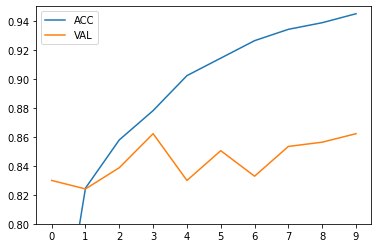

In [56]:
hist = history.history
plt.plot(hist['accuracy'], label='ACC')
plt.plot(hist['val_accuracy'], label= 'VAL')
plt.ylim(.8,.95)
plt.xticks(np.arange(10))
plt.legend()

### Using the model in Epoch 3

In [65]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

In [59]:
test_gen = ImageDataGenerator(preprocessing_function= preprocess_input)

test_ds = test_gen.flow_from_directory(test_path,target_size=(224,224),
                                      batch_size=32,
                                      shuffle= False,
                                      )

Found 372 images belonging to 10 classes.


In [60]:
model = keras.models.load_model('MobileNetsV2.04-0.86.h5')

In [61]:
model.evaluate(test_ds)

12/12 [==============================] - 9s 705ms/step - loss: 0.4222 - accuracy: 0.8548


[0.42215994000434875, 0.8548387289047241]

 #### the model is not overfitting and score almost the same as the validation dataset

In [63]:
path = 'clothing-dataset-small/test/skirt/309829b2-6d1a-4173-8d46-2dbdd10aad90.jpg'

img1 = load_img(path, target_size=(224,224))

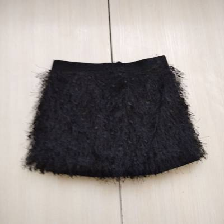

In [64]:
img1

In [68]:
X = np.array([np.array(img1)])
X.shape

(1, 224, 224, 3)

In [69]:
X = preprocess_input(X)

In [70]:
pred = model.predict(X)

In [74]:
pred[0]

array([ 2.773698  , -0.82583624, -1.0938864 , -0.50719523, -1.3390276 ,
       -4.9384007 , -1.8393123 ,  2.1405294 ,  8.506054  ,  0.44137374],
      dtype=float32)

In [72]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [83]:
prediction = dict(zip(classes, pred[0]))

max_score = 0
for item, score in prediction.items():
    if score > max_score :
        max_score = score
        label = item
label

'skirt'